In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
sns.set(style="whitegrid")


In [73]:
# STEP 1: Load Dataset

df = pd.read_csv("Downloads/retail_data.csv")

print("Dataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
  Order No  Order Date           Customer Name  \
0   4293-1  02-09-2014        Vivek Sundaresam   
1   5001-1  24-10-2015          Shahid Hopkins   
2   5004-1  13-03-2014           Dennis Pardue   
3   5009-1  18-02-2013              Sean Wendt   
4   5010-1  13-09-2014  Christina Vanderzanden   

                          Address       City State   Customer Type  \
0  152 Bunnerong Road,Eastgardens     Sydney   NSW  Small Business   
1   438 Victoria Avenue,Chatswood     Sydney   NSW       Corporate   
2        412 Brunswick St,Fitzroy  Melbourne   VIC        Consumer   
3        145 Ramsay St,Haberfield     Sydney   NSW  Small Business   
4          188 Pitt Street,Sydney     Sydney   NSW  Small Business   

  Account Manager Order Priority  \
0    Tina Carlton       Critical   
1    Natasha Song         Medium   
2    Connor Betts  Not Specified   
3     Phoebe Gour       Critical   
4    Tina Carlton  Not Specified   

                                 

In [54]:
# STEP 2: Cleanup & Type Conversion
# - remove $,% and commas
# - parse dates
# - convert numeric columns to float


# Helper to clean currency/percent columns
def clean_currency_percent(series):
    return (series
            .astype(str)
            .str.replace(r'[\$,]', '', regex=True)    # remove $ and commas
            .str.replace(r'%', '', regex=True)        # remove %
            .str.replace(r'--', '', regex=True)      # if there are dashes
            .replace('', np.nan)
            .astype(float))

# Columns in your dataset to convert
to_clean = {
    'Cost Price': 'cost_price',
    'Retail Price': 'retail_price',
    'Profit Margin': 'profit_margin',
    'Order Quantity': 'order_quantity',   # already float but ensure
    'Sub Total': 'sub_total',
    'Discount %': 'discount_pct',
    'Discount $': 'discount_amount',
    'Order Total': 'order_total',
    'Shipping Cost': 'shipping_cost',
    'Total': 'total'
}

# Rename and convert
df = df.rename(columns={k: k for k in df.columns})  # ensure existing
for orig_col, new_name in to_clean.items():
    if orig_col in df.columns:
        df[new_name] = clean_currency_percent(df[orig_col])
    else:
        print(f"Column '{orig_col}' not found in dataframe.")

# Parse dates (if present)
date_cols = ['Order Date', 'Ship Date']
for c in date_cols:
    if c in df.columns:
        df[c + '_parsed'] = pd.to_datetime(df[c], dayfirst=True, errors='coerce')

# Quick check after cleaning
print("\n--- After cleaning: types & missing ---")
display(df[[c for c in df.columns if c in list(to_clean.values())]].info())
display(df[[c for c in df.columns if c in list(to_clean.values())]].describe())



--- After cleaning: types & missing ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cost_price       5000 non-null   float64
 1   retail_price     5000 non-null   float64
 2   profit_margin    5000 non-null   float64
 3   order_quantity   4999 non-null   float64
 4   sub_total        5000 non-null   float64
 5   discount_pct     5000 non-null   float64
 6   discount_amount  5000 non-null   float64
 7   order_total      5000 non-null   float64
 8   shipping_cost    5000 non-null   float64
 9   total            5000 non-null   float64
dtypes: float64(10)
memory usage: 390.8 KB


None

,cost_price,retail_price,profit_margin,order_quantity,sub_total,discount_pct,discount_amount,order_total,shipping_cost,total
count,5000.00,5000.00,5000.00,4999.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,20.39,38.29,18.00,26.48,783.59,5.03,49.43,761.80,5.46,746.31
std,57.14,99.14,44.70,14.39,2444.09,3.23,237.28,2361.54,7.98,2283.43
min,0.24,1.14,0.36,1.00,1.88,0.00,0.00,1.71,0.49,2.85
25%,1.84,2.94,1.32,13.00,65.10,2.00,2.24,62.19,1.01,63.46
50%,3.50,5.74,2.33,27.00,144.00,5.00,5.64,136.01,2.85,137.50
75%,8.85,19.98,8.50,39.00,431.00,8.00,18.86,410.48,6.50,407.10
max,377.99,599.99,430.18,50.00,31699.82,10.00,6094.90,28299.51,69.30,26725.06


In [56]:
# STEP 3: Handle missing values & outliers (order-level)
# - small imputation or drop if row missing key numeric

# Drop rows missing essential numeric info (order_total or order_quantity)
df = df.dropna(subset=['order_total', 'order_quantity'], how='any')
df.reset_index(drop=True, inplace=True)

# Cap extreme outliers using IQR (per numeric column)
num_cols = [c for c in to_clean.values() if c in df.columns]
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


In [58]:
# STEP 4: Aggregate orders to customer-level
# We want to cluster customers, not orders
# Compute: total_spend, avg_order_value, total_orders,
# median_order_qty, avg_profit_margin, avg_discount_pct, avg_shipping_cost

group_col = 'Customer Name'   # if multiple columns identify a customer you can combine them

cust = df.groupby(group_col).agg(
    total_spend = ('order_total', 'sum'),
    avg_order_value = ('order_total', 'mean'),
    total_orders = ('Order No', 'nunique'),
    avg_order_qty = ('order_quantity', 'mean'),
    avg_profit_margin = ('profit_margin', 'mean'),
    avg_discount_pct = ('discount_pct', 'mean'),
    avg_shipping_cost = ('shipping_cost', 'mean')
).reset_index()

# Replace missing numeric aggregations (if any) with 0 or median
numeric_agg_cols = ['total_spend','avg_order_value','total_orders','avg_order_qty',
                    'avg_profit_margin','avg_discount_pct','avg_shipping_cost']
cust[numeric_agg_cols] = cust[numeric_agg_cols].fillna(0)

print("\nAggregated to customer-level — sample:")
display(cust.head())



Aggregated to customer-level — sample:


,Customer Name,total_spend,avg_order_value,total_orders,avg_order_qty,avg_profit_margin,avg_discount_pct,avg_shipping_cost
0,Aaron Bergman,6347.88,264.50,24,27.50,6.50,4.58,6.07
1,Aaron Smayling,4306.12,331.24,11,28.77,6.45,5.85,4.19
2,Adam Bellavance,1385.96,461.99,3,15.33,13.06,9.00,6.84
3,Adam Berlavance,591.95,591.95,1,18.00,1.32,10.00,5.47
4,Adam Hart,133.66,133.66,1,10.00,2.86,10.00,0.83



--- Aggregated features summary ---


,total_spend,avg_order_value,total_orders,avg_order_qty,avg_profit_margin,avg_discount_pct,avg_shipping_cost
count,788.00,788.00,788.00,788.00,788.00,788.00,788.00
mean,1827.55,280.79,5.65,26.46,6.04,4.96,4.40
std,2662.30,234.06,7.02,10.44,5.21,2.35,3.17
min,3.08,3.08,1.00,1.00,0.43,0.00,0.49
25%,156.32,110.37,1.00,21.00,1.86,3.55,1.99
50%,682.03,217.86,2.00,26.87,4.59,5.00,3.99
75%,2425.18,379.00,8.00,32.28,8.33,6.26,5.98
max,16485.81,933.38,45.00,50.00,19.27,10.00,14.73


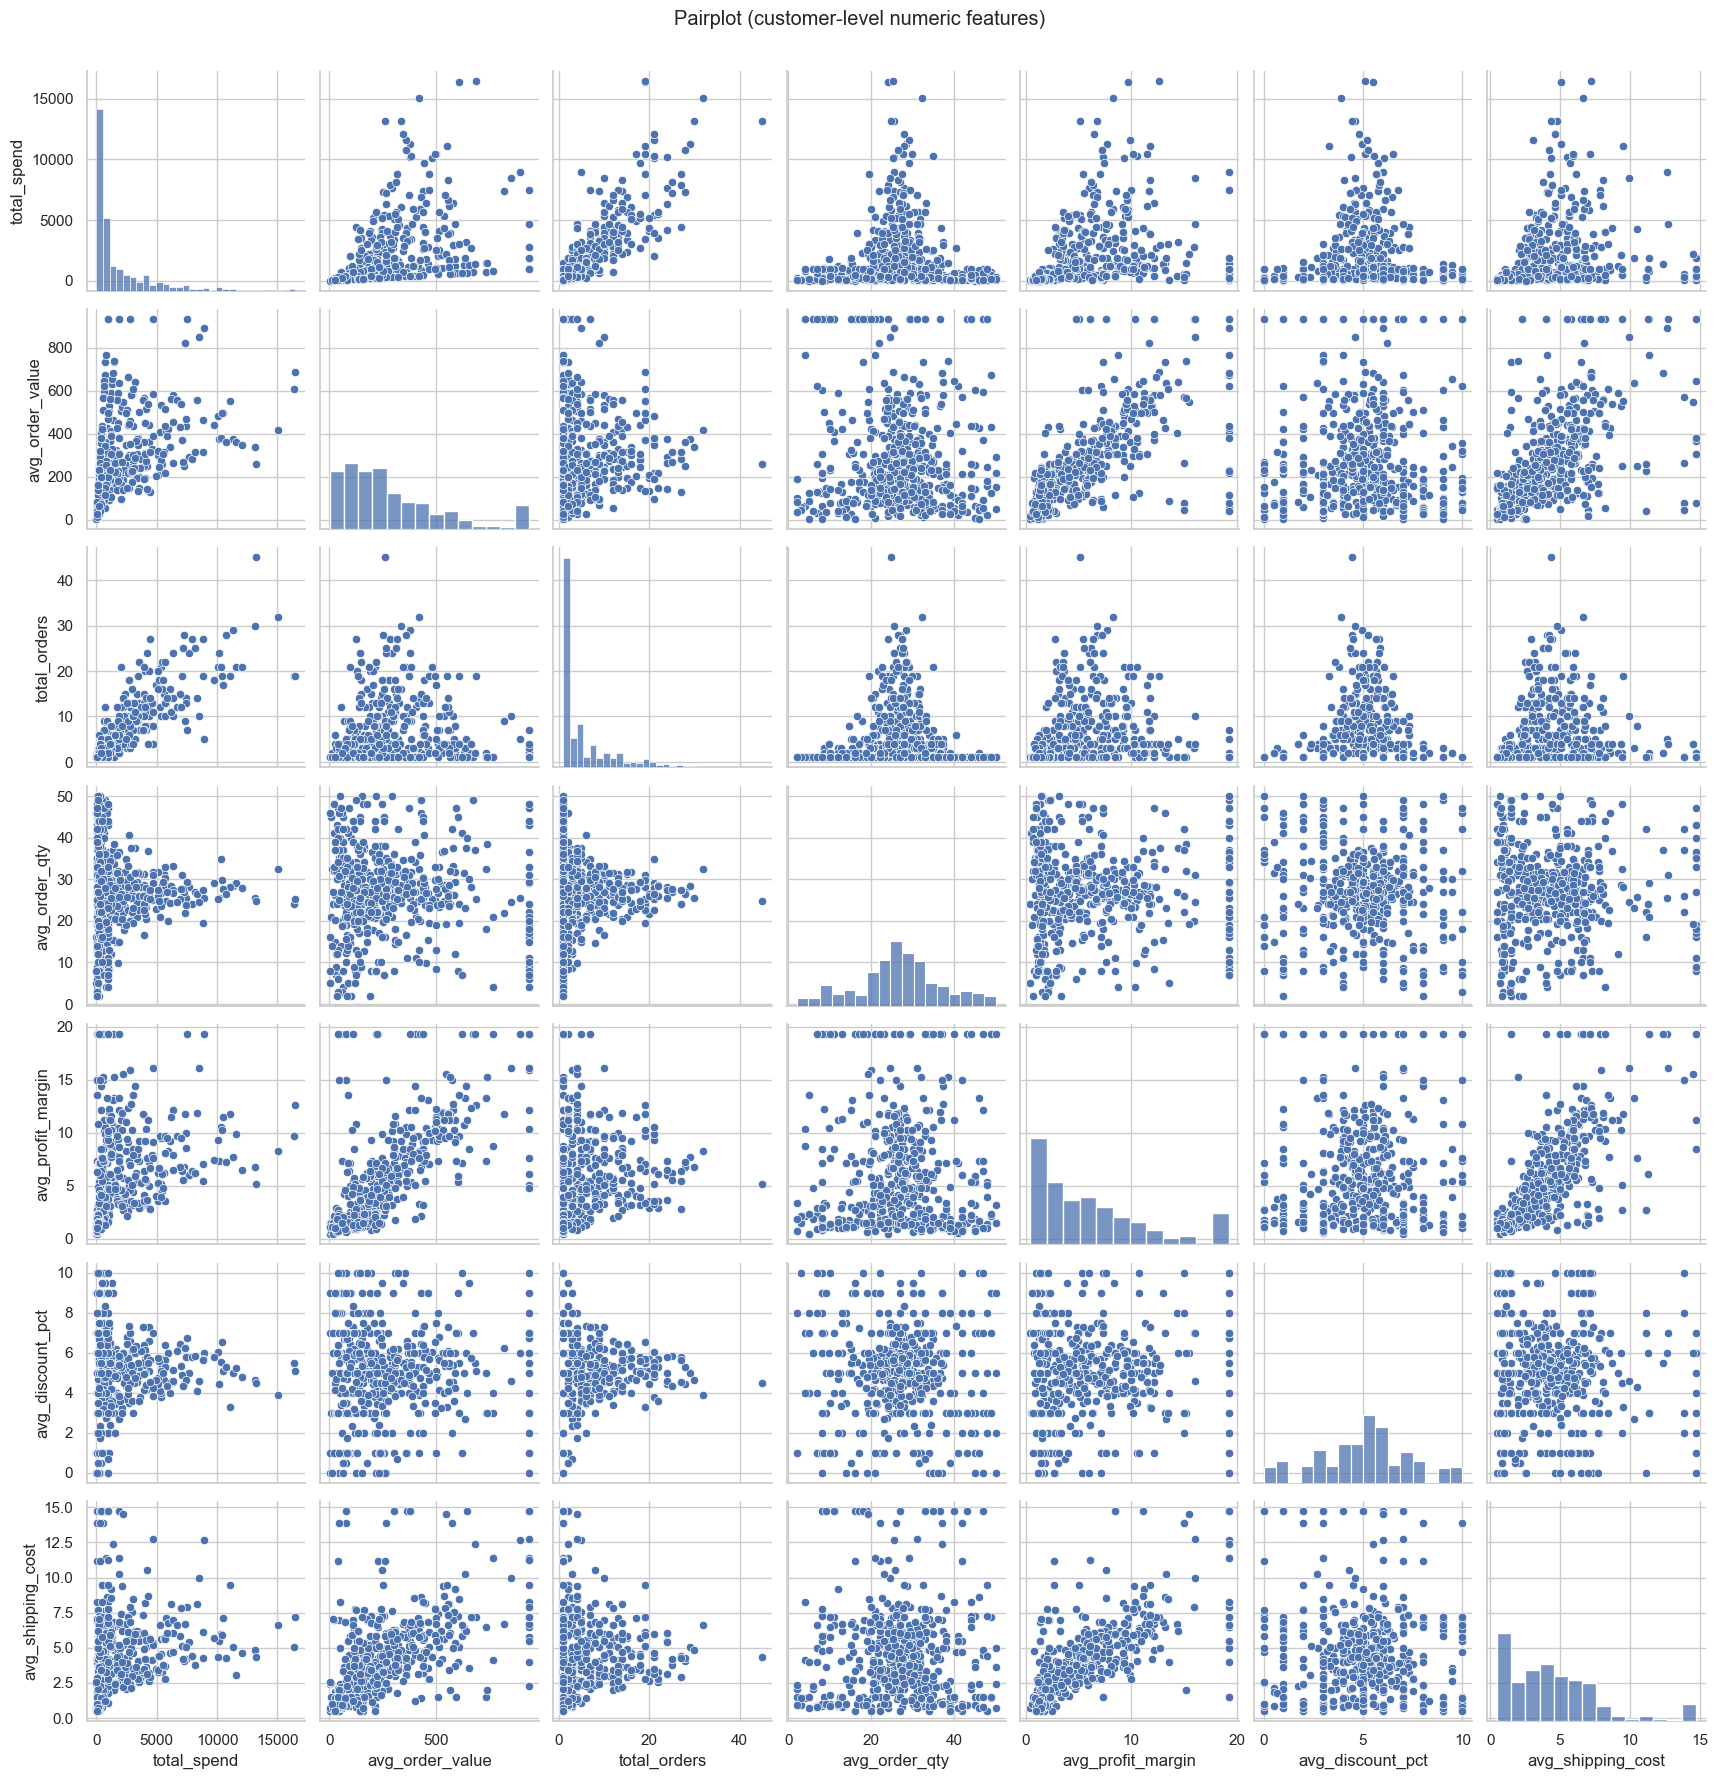

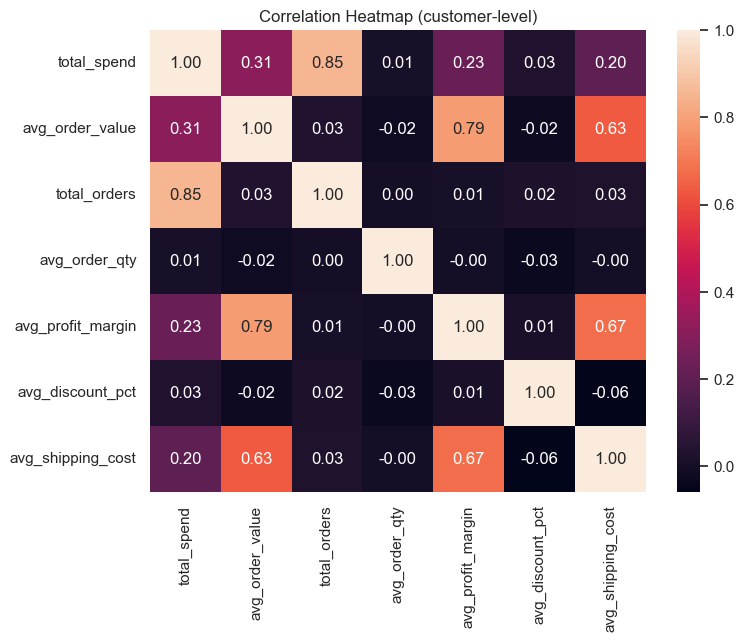

In [60]:
# STEP 5: EDA on aggregated features

print("\n--- Aggregated features summary ---")
display(cust[numeric_agg_cols].describe())

# Pairplot (use a subsample if many customers)
sample_for_plot = cust[numeric_agg_cols].sample(min(500, len(cust)), random_state=42)
sns.pairplot(sample_for_plot)
plt.suptitle("Pairplot (customer-level numeric features)", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cust[numeric_agg_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (customer-level)")
plt.show()


In [61]:
# STEP 6: Feature selection & scaling
# Choose features relevant to segmentation (you can tweak this)

features = cust[['total_spend','avg_order_value','total_orders','avg_profit_margin','avg_discount_pct','avg_shipping_cost', 'avg_order_qty']].copy()

# Log-transform skewed money features to reduce skew (add small constant to avoid log(0))
features['total_spend_log'] = np.log1p(features['total_spend'])
features['avg_order_value_log'] = np.log1p(features['avg_order_value'])

# Drop raw highly skewed originals if you use logs (optional)
features_for_clustering = features[['total_spend_log','avg_order_value_log','total_orders',
                                    'avg_order_qty' if 'avg_order_qty' in features.columns else 'avg_order_qty',
                                    'avg_profit_margin','avg_discount_pct','avg_shipping_cost']].copy()

# If avg_order_qty didn't exist in the features selection earlier, recompute from cust
if 'avg_order_qty' not in features_for_clustering.columns:
    features_for_clustering['avg_order_qty'] = cust['avg_order_qty']

# Ensure all columns are numeric
features_for_clustering = features_for_clustering.fillna(0).astype(float)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_for_clustering)

print("\nFeatures prepared and scaled for clustering. Shape:", X_scaled.shape)



Features prepared and scaled for clustering. Shape: (788, 7)


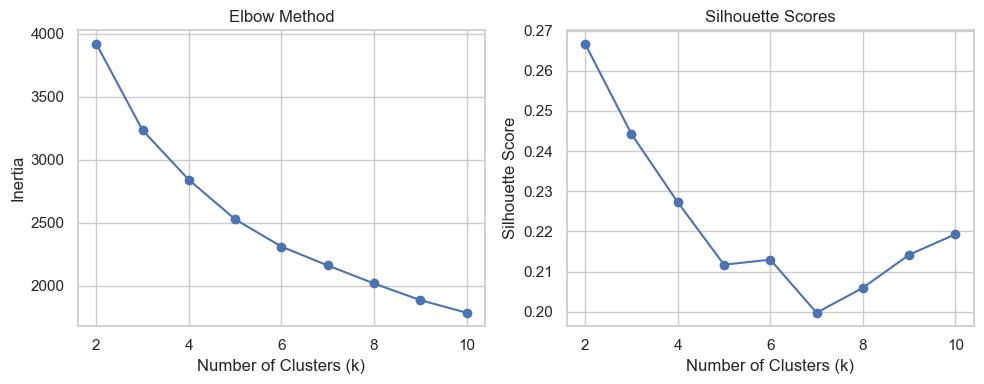


 Suggested number of clusters (based on silhouette): k = 2


In [62]:
# STEP 7: Find optimal K (Elbow + Silhouette)

inertia = []
sil_scores = []
K_range = range(2, 11)   # silhouette not defined for k=1
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(list(K_range), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot silhouette
plt.subplot(1,2,2)
plt.plot(list(K_range), sil_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.tight_layout()
plt.show()

# Choose k: pick the knee in elbow and/or highest silhouette. Example: choose k where silhouette is maximized.
best_k = int(K_range[np.argmax(sil_scores)])
print(f"\n Suggested number of clusters (based on silhouette): k = {best_k}")



In [63]:
# STEP 8: Apply K-Means with chosen K

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cust['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nK-Means clustering applied. Cluster counts:")
display(cust['Cluster'].value_counts().sort_index())




K-Means clustering applied. Cluster counts:


Cluster
0    437
1    351
Name: count, dtype: int64

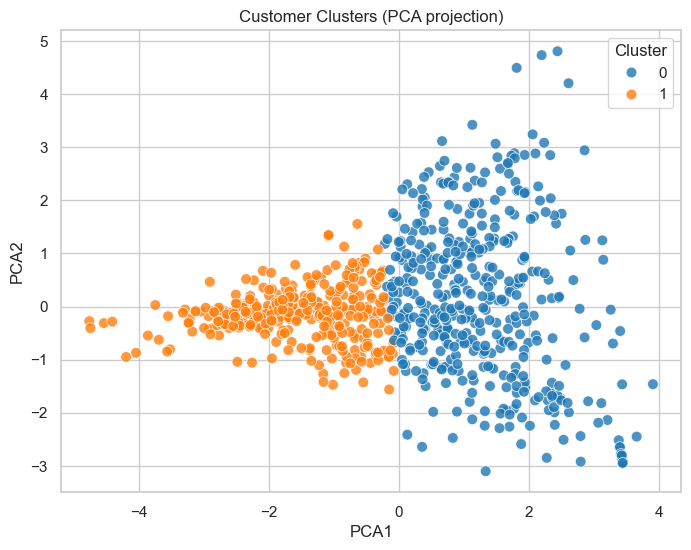

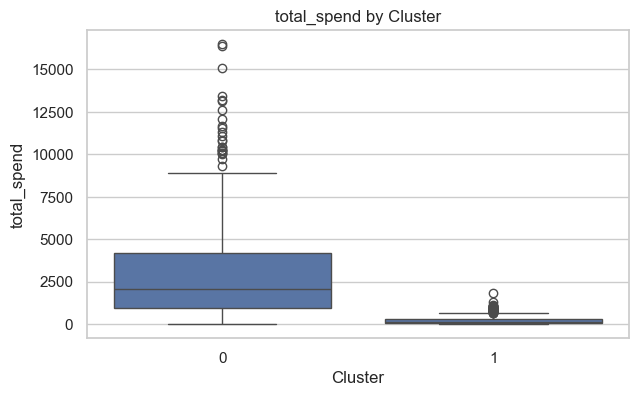

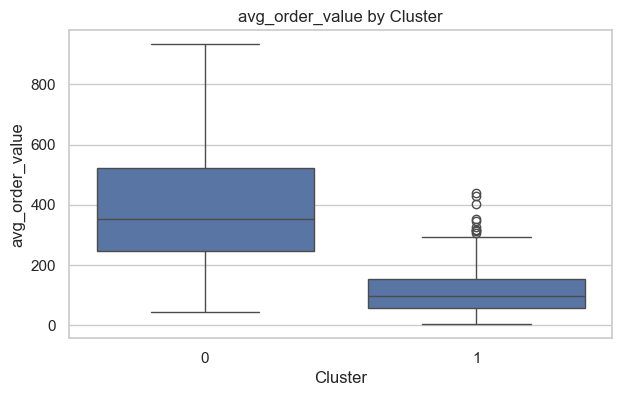

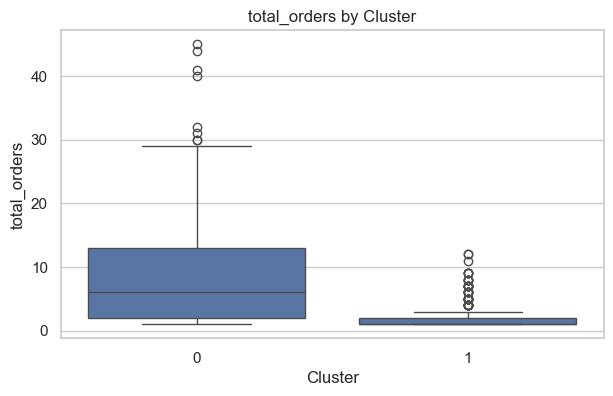

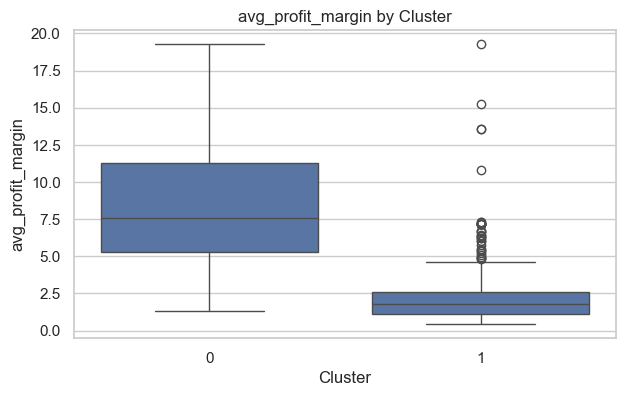

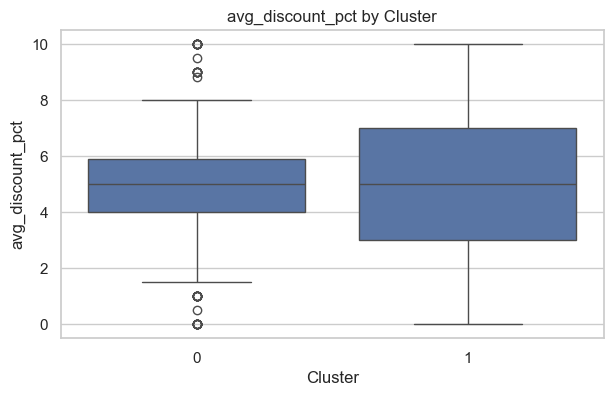

In [64]:
# STEP 9: Visualize clusters (PCA 2D)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)
cust['PCA1'] = Z[:,0]
cust['PCA2'] = Z[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=cust, palette='tab10', s=60, alpha=0.8)
plt.title('Customer Clusters (PCA projection)')
plt.legend(title='Cluster')
plt.show()

# Boxplots of key features by cluster for interpretation
for col in ['total_spend','avg_order_value','total_orders','avg_profit_margin','avg_discount_pct']:
    if col in cust.columns:
        plt.figure(figsize=(7,4))
        sns.boxplot(x='Cluster', y=col, data=cust)
        plt.title(f'{col} by Cluster')
        plt.show()


In [65]:
# STEP 10: Summarize clusters & marketing suggestions

cluster_summary = cust.groupby('Cluster').agg(
    customers = (group_col, 'nunique'),
    total_spend_mean = ('total_spend','mean'),
    avg_order_value_mean = ('avg_order_value','mean'),
    total_orders_mean = ('total_orders','mean'),
    avg_profit_margin_mean = ('avg_profit_margin','mean'),
    avg_discount_pct_mean = ('avg_discount_pct','mean')
).round(2).reset_index()

print("\n--- Cluster Summary (customer-level means) ---")
display(cluster_summary)

print("\nSuggested marketing strategies per cluster (illustrative):")
for _, row in cluster_summary.iterrows():
    cid = int(row['Cluster'])
    ts = row['total_spend_mean']
    avg_val = row['avg_order_value_mean']
    pm = row['avg_profit_margin_mean']
    disc = row['avg_discount_pct_mean']
    print(f"\nCluster {cid} (n={int(row['customers'])}):")
    if ts > cluster_summary['total_spend_mean'].quantile(0.75):
        print(" - High lifetime value cluster: prioritize VIP programs, personalized retention, exclusive bundles, and early access offers.")
        if pm > 0:
            print(" - Consider cross-sell higher-margin items; offer premium support or negotiated pricing.")
    elif avg_val > cluster_summary['avg_order_value_mean'].median():
        print(" - Medium order-value customers: push upsell bundles at checkout, targeted promotions for related products.")
    else:
        print(" - Low spenders / price sensitive: target with discount coupons, loyalty points to increase visit frequency.")
    if disc > cluster_summary['avg_discount_pct_mean'].mean():
        print(" - These customers respond to discounts—use targeted timed-offers rather than across-the-board price cuts.")

# Save clustered customer table for future analysis (optional)
cust.to_csv("customers_with_clusters.csv", index=False)
print("\nSaved 'customers_with_clusters.csv' with cluster labels (in current working directory) for future analysis.")



--- Cluster Summary (customer-level means) ---


,Cluster,customers,total_spend_mean,avg_order_value_mean,total_orders_mean,avg_profit_margin_mean,avg_discount_pct_mean
0,0,437,3099.17,415.60,8.54,9.00,4.95
1,1,351,244.37,112.94,2.04,2.36,4.97



Suggested marketing strategies per cluster (illustrative):

Cluster 0 (n=437):
 - High lifetime value cluster: prioritize VIP programs, personalized retention, exclusive bundles, and early access offers.
 - Consider cross-sell higher-margin items; offer premium support or negotiated pricing.

Cluster 1 (n=351):
 - Low spenders / price sensitive: target with discount coupons, loyalty points to increase visit frequency.
 - These customers respond to discounts—use targeted timed-offers rather than across-the-board price cuts.

Saved 'customers_with_clusters.csv' with cluster labels (in current working directory) for future analysis.
